# GME on Arbitrary Bipartite Subgraphs of IQM Emerald

**Idea**: drop the rectangle constraint. The GME witness W = Σ⟨g_i⟩ ≤ n−1 works for **any connected 2-colorable graph state**, not just rectangular cluster states.

**Why this helps**: a spanning tree on n qubits has only n−1 edges (≈ 30% fewer CZ gates than a 2D grid on the same n). Fewer CZ gates → higher prep fidelity → larger n certifies.

**Algorithm**:
1. Pull device calibration data (per-qubit T1, T2, readout, 1Q fidelity; per-edge CZ fidelity)
2. Threshold-filter qubits → 'good' qubit set
3. Restrict device coupling to good qubits + edges with CZ fidelity above threshold
4. For each starting qubit, run Prim's algorithm to grow a min-weight spanning tree of size n
5. Return the lightest tree across all starts

Theory: Tóth & Gühne (2005) — same witness, just a different graph than 2D rectangular.

Mitigation applied: parity-QREM from device-reported readout error rates.

In [ ]:
import sys, time
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import get_backend, is_simulator, select_best_tree, get_qubit_metrics
from src.circuits.graph_state import build_graph_state
from src.witnesses.gme_graph import build_gme_circuits_graph, compute_gme_witness_graph, gme_significance_graph
from src.mitigation.parity_qrem import correction_factors_from_metrics

TARGET_NS = [8, 12, 16, 20]
SHOTS = 1500

# Empirically best configuration: thresholds + CZ-only weights + local search.
# We tested 'no thresholds + quality-weighted edges' in compare_strategies.py
# and it produced consistently lower W on hardware — calibration data alone
# is not fully predictive, and the threshold filter implicitly avoids
# marginal qubits that drift more than reported.
TREE_KWARGS = dict(use_local_search=True)   # other defaults are good

backend = get_backend(device='emerald')
print(f'Backend: {backend} (hardware: {not is_simulator(backend)})')
print(f'Target sizes: {TARGET_NS} qubits, {SHOTS} shots/circuit')

if not is_simulator(backend):
    qm, _ = get_qubit_metrics(backend)
    correction_factors = correction_factors_from_metrics(qm)
else:
    correction_factors = {}

## Find the optimal spanning tree for each target size

No hardware calls here — uses the device's reported calibration data.

In [2]:
trees = {}
for n in TARGET_NS:
    try:
        t = select_best_tree(backend, n, **TREE_KWARGS)
        trees[n] = t
        print(f'n={n:2d}: weight={t["weight"]:.4f}  qubits={t["qubits"]}')
    except ValueError as e:
        print(f'n={n:2d}: {e}')

n= 8: weight=0.1542  qubits=[0, 1, 5, 6, 10, 11, 12, 13]


n=12: weight=0.2739  qubits=[0, 1, 4, 5, 6, 9, 10, 11, 12, 13, 21, 29]


n=16: weight=0.3775  qubits=[0, 1, 4, 5, 6, 9, 10, 11, 12, 13, 21, 28, 29, 36, 44, 50]


n=20: weight=0.4999  qubits=[0, 1, 4, 5, 6, 9, 10, 11, 12, 13, 21, 28, 29, 35, 36, 37, 43, 44, 49, 50]


## Visualise each chosen tree on the device topology

For each target n, plot the full IQM Emerald topology (all 54 qubits + 81 native CZ pairs), with the selected sub-tree highlighted in red. Node colour = readout fidelity, edge diamond colour = CZ fidelity.

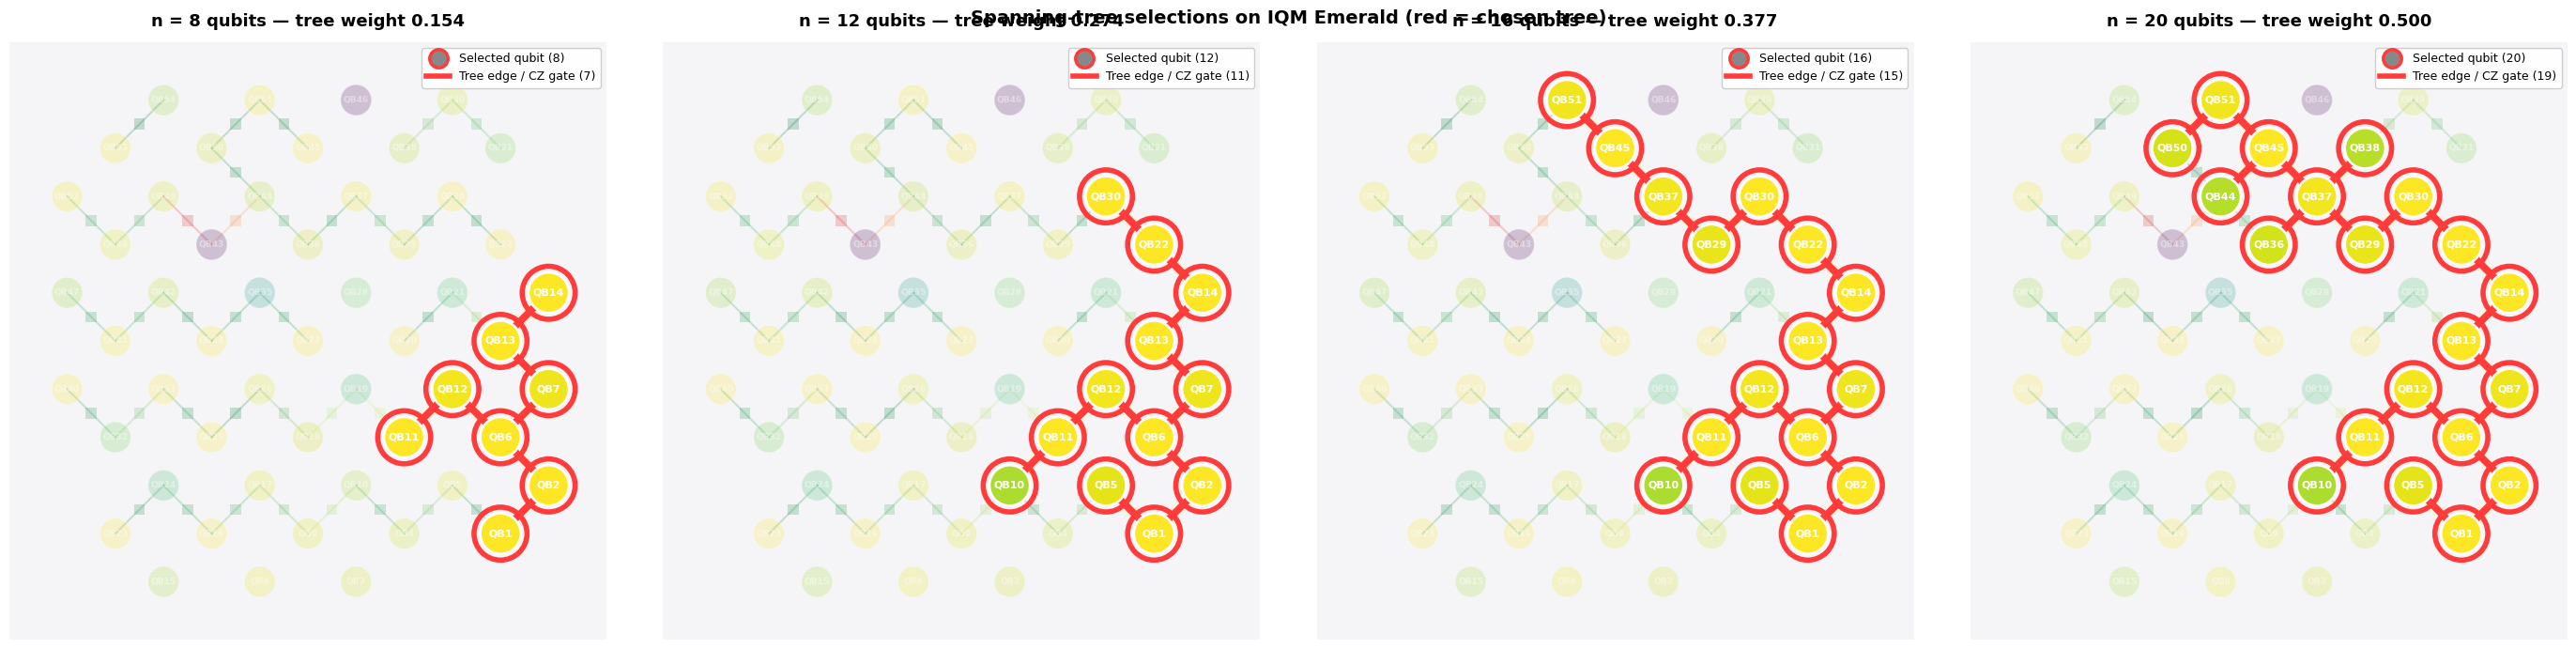

In [3]:
from src.visualization import plot_device_topology, _device_layout

if not is_simulator(backend):
    qm_metrics, cz_pairs = get_qubit_metrics(backend)
    pos = _device_layout(backend)   # compute once, reuse for all panels

    n_trees = len(trees)
    fig, axes = plt.subplots(1, n_trees, figsize=(7 * n_trees, 7), squeeze=False)
    for ax, (n, t) in zip(axes[0], trees.items()):
        plot_device_topology(
            backend, metrics=qm_metrics, cz_fidelities=cz_pairs,
            color_by='readout_fidelity',
            highlight_qubits=t['qubits'],
            highlight_edges=t['edges'],
            title=f'n = {n} qubits — tree weight {t["weight"]:.3f}',
            ax=ax, pos=pos, show_labels=True,
        )
    plt.suptitle('Spanning-tree selections on IQM Emerald (red = chosen tree)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gme_tree_topology.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('Simulator backend — no topology to visualise.')

## Run the witness on hardware for each tree

One IQM job per tree (2 circuits × {SHOTS} shots). Compare raw vs +QREM.

In [4]:
results = []
for n, tree in trees.items():
    print(f'\nn={n} ...', flush=True)
    qubits = tree['qubits']
    log_edges = tree['logical_edges']
    coloring = tree['coloring']
    state = build_graph_state(n, log_edges)
    circ_a, circ_b = build_gme_circuits_graph(state, coloring)

    transpiled = transpile([circ_a, circ_b], backend=backend,
                           initial_layout=qubits, optimization_level=3)
    depth_phys = transpiled[0].depth()
    n_cz_phys = transpiled[0].count_ops().get('cz', 0)

    t0 = time.time()
    job = backend.run(transpiled, shots=SHOTS)
    raw = job.result().get_counts()
    elapsed = time.time() - t0
    counts_a, counts_b = (raw, raw) if isinstance(raw, dict) else (raw[0], raw[1])

    res = compute_gme_witness_graph(counts_a, counts_b, n, log_edges, coloring)
    sigma_raw = gme_significance_graph(res['W'], n, SHOTS)
    stab_raw = res['stabilizer_values']
    raw_arr = np.array(list(stab_raw.values()))

    # Apply parity QREM
    from src.circuits.graph_state import neighbours_from_edges
    nbrs = neighbours_from_edges(n, log_edges)
    stab_mit = {}
    for q in range(n):
        involved_logical = [q] + nbrs[q]
        involved_phys = [qubits[i] for i in involved_logical]
        factor = 1.0
        for p in involved_phys:
            factor *= correction_factors.get(p, 1.0)
        stab_mit[q] = stab_raw[q] * factor
    mit_arr = np.array(list(stab_mit.values()))
    W_mit = float(mit_arr.sum())
    sigma_mit = gme_significance_graph(W_mit, n, SHOTS)
    is_gme_mit = W_mit > n - 1

    results.append({
        'n': n, 'qubits': qubits, 'logical_edges': log_edges, 'coloring': coloring,
        'tree_weight': tree['weight'],
        'depth_physical': depth_phys, 'n_cz_physical': n_cz_phys,
        'W_raw': res['W'], 'W_mit': W_mit, 'bound': n - 1, 'ideal': n,
        'sigma_raw': sigma_raw, 'sigma_mit': sigma_mit,
        'is_gme_raw': res['is_gme'], 'is_gme_mit': is_gme_mit,
        'stab_raw': dict(stab_raw), 'stab_mit': dict(stab_mit),
        'stab_raw_mean': float(raw_arr.mean()), 'stab_raw_std': float(raw_arr.std()),
        'stab_raw_min': float(raw_arr.min()),
        'stab_mit_mean': float(mit_arr.mean()), 'stab_mit_std': float(mit_arr.std()),
        'stab_mit_min': float(mit_arr.min()),
        'shots': SHOTS, 'job_elapsed_s': elapsed,
    })
    print(f'  RAW : W={res["W"]:.3f}/{n}  σ={sigma_raw:6.2f}  ⟨g⟩={raw_arr.mean():.3f}  GME={"✓" if res["is_gme"] else "✗"}')
    print(f'  +QREM: W={W_mit:.3f}/{n}  σ={sigma_mit:6.2f}  ⟨g⟩={mit_arr.mean():.3f}  GME={"✓" if is_gme_mit else "✗"}')
    print(f'  depth={depth_phys}  CZs={n_cz_phys} ({n-1} logical)  job={elapsed:.1f}s')


n=8 ...


  RAW : W=7.229/8  σ=  3.14  ⟨g⟩=0.904  GME=✓
  +QREM: W=7.637/8  σ=  8.73  ⟨g⟩=0.955  GME=✓
  depth=8  CZs=7 (7 logical)  job=5.4s

n=12 ...


  RAW : W=10.472/12  σ= -5.90  ⟨g⟩=0.873  GME=✗
  +QREM: W=11.152/12  σ=  1.70  ⟨g⟩=0.929  GME=✓
  depth=11  CZs=11 (11 logical)  job=5.6s

n=16 ...


  RAW : W=13.748/16  σ=-12.12  ⟨g⟩=0.859  GME=✗
  +QREM: W=14.667/16  σ= -3.23  ⟨g⟩=0.917  GME=✗
  depth=15  CZs=15 (15 logical)  job=5.7s

n=20 ...


  RAW : W=16.881/20  σ=-18.35  ⟨g⟩=0.844  GME=✗
  +QREM: W=18.192/20  σ= -6.99  ⟨g⟩=0.910  GME=✗
  depth=16  CZs=19 (19 logical)  job=6.9s


## Summary

In [5]:
import pandas as pd
df = pd.DataFrame([
    {
        'n': r['n'], 'bound': r['bound'],
        'W raw': round(r['W_raw'], 2), 'σ raw': round(r['sigma_raw'], 1),
        '⟨g⟩ raw': round(r['stab_raw_mean'], 3),
        'W +QREM': round(r['W_mit'], 2), 'σ +QREM': round(r['sigma_mit'], 1),
        '⟨g⟩ +QREM': round(r['stab_mit_mean'], 3),
        'CZs': r['n_cz_physical'], 'depth': r['depth_physical'],
        'tree weight': round(r['tree_weight'], 3),
        'GME (raw)': '✓' if r['is_gme_raw'] else '✗',
        'GME (mit)': '✓' if r['is_gme_mit'] else '✗',
    } for r in results
])
print(df.to_string(index=False))
print()
max_raw = max((r['n'] for r in results if r['is_gme_raw']), default=0)
max_mit = max((r['n'] for r in results if r['is_gme_mit']), default=0)
print(f'Max GME certified raw : {max_raw}')
print(f'Max GME certified +QREM: {max_mit}')

 n  bound  W raw  σ raw  ⟨g⟩ raw  W +QREM  σ +QREM  ⟨g⟩ +QREM  CZs  depth  tree weight GME (raw) GME (mit)
 8      7   7.23    3.1    0.904     7.64      8.7      0.955    7      8        0.154         ✓         ✓
12     11  10.47   -5.9    0.873    11.15      1.7      0.929   11     11        0.274         ✗         ✓
16     15  13.75  -12.1    0.859    14.67     -3.2      0.917   15     15        0.377         ✗         ✗
20     19  16.88  -18.3    0.844    18.19     -7.0      0.910   19     16        0.500         ✗         ✗

Max GME certified raw : 8
Max GME certified +QREM: 12


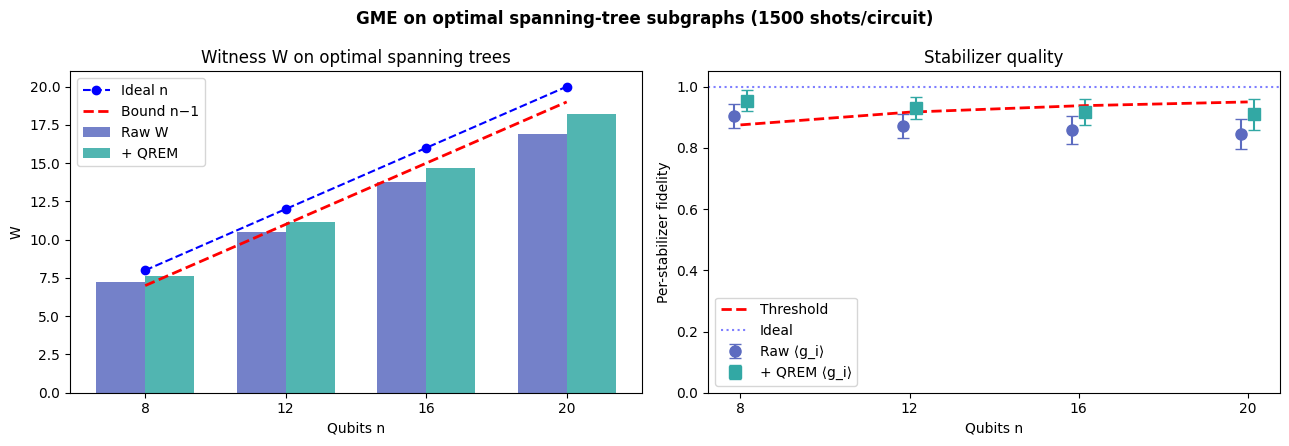

In [6]:
ns = [r['n'] for r in results]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
x = np.arange(len(ns)); w = 0.35
ax.bar(x - w/2, [r['W_raw'] for r in results], w, color='#5c6bc0', alpha=0.85, label='Raw W')
ax.bar(x + w/2, [r['W_mit'] for r in results], w, color='#32a8a4', alpha=0.85, label='+ QREM')
ax.plot(x, ns, 'b--o', label='Ideal n')
ax.plot(x, [n-1 for n in ns], 'r--', linewidth=2, label='Bound n−1')
ax.set_xticks(x); ax.set_xticklabels([f'{n}' for n in ns])
ax.set_xlabel('Qubits n'); ax.set_ylabel('W')
ax.set_title('Witness W on optimal spanning trees')
ax.legend()

ax = axes[1]
ax.errorbar(np.array(ns)-0.15, [r['stab_raw_mean'] for r in results],
            yerr=[r['stab_raw_std'] for r in results], fmt='o', color='#5c6bc0',
            label='Raw ⟨g_i⟩', markersize=8, capsize=4)
ax.errorbar(np.array(ns)+0.15, [r['stab_mit_mean'] for r in results],
            yerr=[r['stab_mit_std'] for r in results], fmt='s', color='#32a8a4',
            label='+ QREM ⟨g_i⟩', markersize=8, capsize=4)
ax.plot(ns, [(n-1)/n for n in ns], 'r--', linewidth=2, label='Threshold')
ax.axhline(1.0, color='blue', linestyle=':', alpha=0.5, label='Ideal')
ax.set_xlabel('Qubits n'); ax.set_ylabel('Per-stabilizer fidelity')
ax.set_title('Stabilizer quality')
ax.set_xticks(ns); ax.set_ylim(0, 1.05); ax.legend(loc='lower left')

plt.suptitle(f'GME on optimal spanning-tree subgraphs ({SHOTS} shots/circuit)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gme_tree_results.png', dpi=150, bbox_inches='tight')
plt.show()